### Pruebo ajustar gaussiana a datos

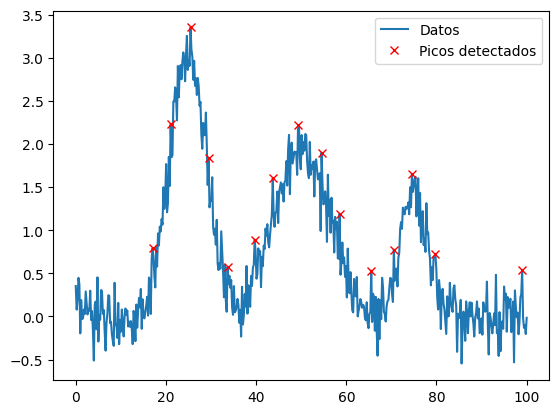

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 9200.

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Función suma de gaussianas ---
def multi_gauss(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i:i+3]
        y += A * np.exp(-(x-mu)**2 / (2*sigma**2))
    return y

# --- Datos sintéticos con 3 gaussianas ---
np.random.seed(0)
x = np.linspace(0, 100, 500)
y = (3*np.exp(-(x-25)**2/(2*4**2)) +
     2*np.exp(-(x-50)**2/(2*6**2)) +
     1.5*np.exp(-(x-75)**2/(2*3**2)) +
     0.2*np.random.normal(size=len(x)))

# --- Detección de picos ---
peaks, _ = find_peaks(y, height=0.5, distance=20)  # "distance" evita picos muy juntos
plt.plot(x, y, label="Datos")
plt.plot(x[peaks], y[peaks], "rx", label="Picos detectados")
plt.legend()
plt.show()

# --- Parámetros iniciales (A, mu, sigma) para cada pico ---
p0 = []
for peak in peaks:
    A_init = y[peak]         # altura estimada
    mu_init = x[peak]        # posición estimada
    sigma_init = 5           # ancho inicial "aprox"
    p0 += [A_init, mu_init, sigma_init]

# --- Ajuste ---
popt, pcov = curve_fit(multi_gauss, x, y, p0=p0)

# --- Graficar resultados ---
plt.scatter(x, y, s=5, label="Datos")
plt.plot(x, multi_gauss(x, *popt), 'r-', label="Ajuste total")

# Graficar cada gaussiana individual
for i in range(0, len(popt), 3):
    A, mu, sigma = popt[i:i+3]
    plt.plot(x, A*np.exp(-(x-mu)**2/(2*sigma**2)), '--', label=f"Pico en {mu:.1f}")

plt.legend()
plt.show()

### Pruebo

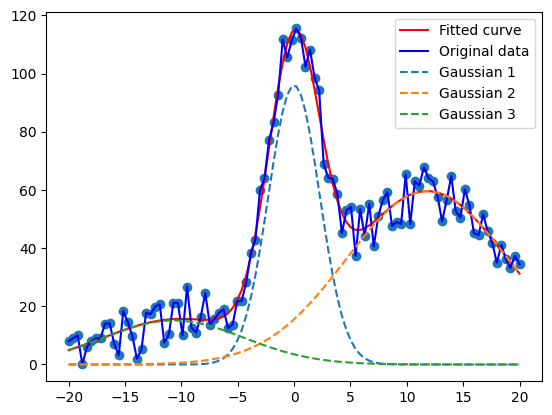

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Multi-gaussian plot of sample data ---

# create data points
x = np.linspace(-20,20,100)

# y = y1 + y2 + noise
y = 10*np.exp(-(x+8)**2/15) + 100*np.exp(-(x-0)**2/10) + 50*np.exp(-(x-12)**2/80) + np.random.randint(0,20,x.size)

# define function
def multi_gauss(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3):
    return a1*np.exp(-(x-mu1)**2/sigma1) + a2*np.exp(-(x-mu2)**2/sigma2) + a3*np.exp(-(x-mu3)**2/sigma3)

def gauss(x,a,mu,sigma):
    return a*np.exp(-(x-mu)**2/sigma)

# do fitting
p_ini=[100, 0, 10, 50, 5, 100, 20, -8, 15] # initial guess
popt, pcov = curve_fit(multi_gauss, x, y, p0=p_ini)

# plot fitted curve
y_fit = multi_gauss(x, *popt)
plt.plot(x,y_fit, color='red', label='Fitted curve')
plt.plot(x, y, color='blue', label='Original data')

plt.plot(x, gauss(x, *popt[:3]), '--', label='Gaussian 1')
plt.plot(x, gauss(x, *popt[3:6]), '--', label='Gaussian 2')
plt.plot(x, gauss(x, *popt[6:]), '--', label='Gaussian 3')

plt.scatter(x,y)

plt.legend()
plt.show()